# DSA211 Statistical Learning
## Week 4 Lab: Regression Diagnostics in Python

**Learning objectives**

By the end of this lab you will be able to:

- Produce the four standard regression diagnostic plots using `statsmodels`
- Produce added variable plots, and compare predictors with partial correlation
- Compute and interpret leverage, Cook's distance, and DFFITS
- Use `variance_inflation_factor` to detect collinearity
- Apply a principled workflow to investigate and adjudicate flagged observations

**Dataset:** We use the `Credit` dataset (ISLP), which records balance, income, credit limit, and demographic information for 400 credit card customers. The modelling goal is to explain credit card `Balance`.

**Note:** EDA is omitted in Parts 1–5 (covered on the primary dataset in Part 0). Comments flag where you would include it in real practice.

***

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence, variance_inflation_factor
from statsmodels.graphics.regressionplots import plot_partregress_grid

***

## Part 0: EDA on the Credit Dataset

In [2]:
# Load data
url = "https://www.statlearning.com/s/Credit.csv"
credit = pd.read_csv(url)
credit.index = range(1, len(credit) + 1)

# Drop unnamed index column if present
if "Unnamed: 0" in credit.columns:
    credit = credit.drop(columns=["Unnamed: 0"])

In [4]:
print("Shape:", credit.shape)
print() # adds a vertical gap
print(credit.head())
print()
print("Customers with Balance = 0:", (credit["Balance"] == 0).sum())

Shape: (400, 11)

    Income  Limit  Rating  Cards  Age  Education  Own Student Married Region  \
1   14.891   3606     283      2   34         11   No      No     Yes  South   
2  106.025   6645     483      3   82         15  Yes     Yes     Yes   West   
3  104.593   7075     514      4   71         11   No      No      No   West   
4  148.924   9504     681      3   36         11  Yes      No      No   West   
5   55.882   4897     357      2   68         16   No      No     Yes  South   

   Balance  
1      333  
2      903  
3      580  
4      964  
5      331  

Customers with Balance = 0: 90


In [5]:
# Correlation matrix for numeric predictors (two line, no-frill version)
corr = credit.select_dtypes(include=np.number).corr() # compute correlation of numeric varaibles
corr.style.background_gradient(cmap="RdBu_r", vmin=-1, vmax=1).format("{:.3f}") # add colour

,Income,Limit,Rating,Cards,Age,Education,Balance
Income,1.000,0.792,0.791,-0.018,0.175,-0.028,0.464
Limit,0.792,1.000,0.997,0.010,0.101,-0.024,0.862
Rating,0.791,0.997,1.000,0.053,0.103,-0.030,0.864
Cards,-0.018,0.010,0.053,1.000,0.043,-0.051,0.086
Age,0.175,0.101,0.103,0.043,1.000,0.004,0.002
Education,-0.028,-0.024,-0.030,-0.051,0.004,1.000,-0.008
Balance,0.464,0.862,0.864,0.086,0.002,-0.008,1.000


> **Discussion 0.1:** Look at the correlation matrix. Which pairs of predictors are strongly correlated? How might this affect our model?


***

## Part 1: Fit a Multiple Regression Model

We fit: `Balance ~ Income + Limit + Rating + Age + Student`

In [ ]:
# Fit model using formula API — C() handles dummy encoding automatically
model = smf.ols(
    "Balance ~ Income + Limit + Rating + Age + C(Student)",
    data=credit
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Balance   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     1585.
Date:                Sun, 06 Sep 2026   Prob (F-statistic):          2.25e-258
Time:                        13:29:51   Log-Likelihood:                -2409.4
No. Observations:                 400   AIC:                             4831.
Df Residuals:                     394   BIC:                             4855.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          -486.6144     25.28

> **Discussion 1.1:** `Rating` and `Limit` have a correlation of about 0.99. Suppose you drop `Rating` and refit. Before running anything: do you expect the *coefficient* on `Limit` to change a lot or a little? What about its *standard error*? And what about $R^2$?


***

## Part 2: The Four Standard Diagnostic Plots

We start by computing the

- leverage,
- studentised residuals,
- Cook's distance

because the fourth plot needs them and Part 4 uses them again.

`hat_matrix_diag` comes back as a plain numpy array, while cooks_distance and the studentised residuals come back as pandas Series. Wrap `leverage` in a Series with the same index so every influence measure can be indexed by observation label.

In [ ]:
fitted    = model.fittedvalues
residuals = model.resid
influence = OLSInfluence(model)
leverage        = pd.Series(influence.hat_matrix_diag,
                            index=credit.index) # wrapped
std_resid       = influence.resid_studentized_internal   # internally studentised
studentised_ext = influence.resid_studentized_external   # externally studentised
cooks_d         = influence.cooks_distance[0]

n = model.nobs
p = model.df_model                 # number of predictors, excluding the intercept
lev_threshold = 2 * (p + 1) / n    # used again later

Below we plot all four plots together. In the lecture, the plots were given individually. The first three test the Gauss–Markov assumptions; the fourth looks for observations distorting the fit.

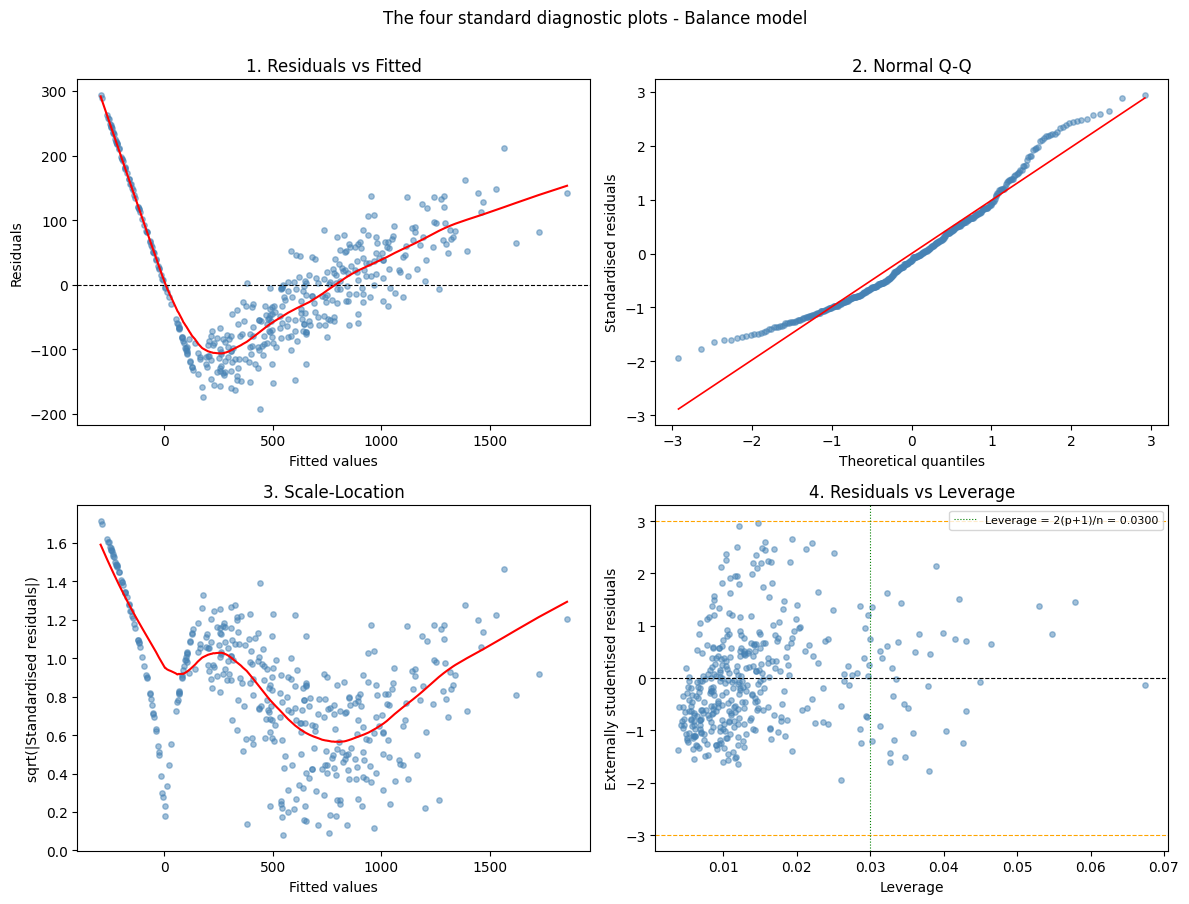

Largest |externally studentised residual|: 2.968
Observations above the leverage threshold: 38


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1 - Residuals vs Fitted: linearity
ax = axes[0, 0] # position
ax.scatter(fitted, residuals, alpha=0.5, s=15, color='steelblue')
ax.axhline(0, color='black', lw=0.8, ls='--')
lo = sm.nonparametric.lowess(residuals, fitted, frac=0.3) # lowess
ax.plot(lo[:, 0], lo[:, 1], color='red', lw=1.5)
ax.set(xlabel="Fitted values", ylabel="Residuals", title="1. Residuals vs Fitted")

# 2 - Normal Q-Q: normality of the errors
ax = axes[0, 1]
(osm, osr), (slope, intercept, r) = scipy_stats.probplot(std_resid, dist="norm")
ax.scatter(osm, osr, alpha=0.5, s=15, color='steelblue')
ax.plot(osm, slope * np.array(osm) + intercept, color='red', lw=1.2)
ax.set(xlabel="Theoretical quantiles", ylabel="Standardised residuals", title="2. Normal Q-Q")

# 3 - Scale-Location: constant variance
ax = axes[1, 0]
sqrt_abs_resid = np.sqrt(np.abs(std_resid))
ax.scatter(fitted, sqrt_abs_resid, alpha=0.5, s=15, color='steelblue')
lo2 = sm.nonparametric.lowess(sqrt_abs_resid, fitted, frac=0.3)
ax.plot(lo2[:, 0], lo2[:, 1], color='red', lw=1.5)
ax.set(xlabel="Fitted values", ylabel="sqrt(|Standardised residuals|)",
       title="3. Scale-Location")

# 4 - Residuals vs Leverage: influence
ax = axes[1, 1]
ax.scatter(leverage, studentised_ext, alpha=0.5, s=15, color='steelblue')
ax.axhline(0, color='black', lw=0.8, ls='--')
for y in (3, -3):
    ax.axhline(y, color='orange', lw=0.8, ls='--')
ax.axvline(lev_threshold, color='green', lw=0.8, ls=':',
           label=f"Leverage = 2(p+1)/n = {lev_threshold:.4f}")
ax.legend(fontsize=8)
ax.set(xlabel="Leverage", ylabel="Externally studentised residuals",
       title="4. Residuals vs Leverage")

plt.suptitle("The four standard diagnostic plots - Balance model", y=1.00)
plt.tight_layout()
plt.show()

print(f"Largest |externally studentised residual|: {studentised_ext.abs().max():.3f}")
print(f"Observations above the leverage threshold: {(leverage > lev_threshold).sum()}")

❓ **Question 2.1** Read all four panels and fill in the table. One or two sentences per cell.

| Plot | What you see | What it tells you about the model |
|---|---|---|
| 1. Residuals vs Fitted | | |
| 2. Normal Q–Q | | |
| 3. Scale–Location | | |
| 4. Residuals vs Leverage | | |

Then in one sentence: **which of the four is the most serious problem here, and why?**

*Watch the direction on panel 1. A residual is $y - \hat{y}$, so a positive residual means the model came in too low.*

*Your answer here:*

In [ ]:
skew = std_resid.skew()
kurt = std_resid.kurt()
print(f"Skewness: {skew:.4f}")
print(f"Excess kurtosis: {kurt:.4f}")   # pandas returns EXCESS kurtosis;
                                        # the model summary reports Pearson (= excess + 3)

Skewness: 0.6925
Excess kurtosis: 0.0075


***

## Part 3: Added Variable Plots

`plot_partregress_grid` produces the set of added variable plots for every predictor in a fitted model. Convenient, but the axis labels are terse.

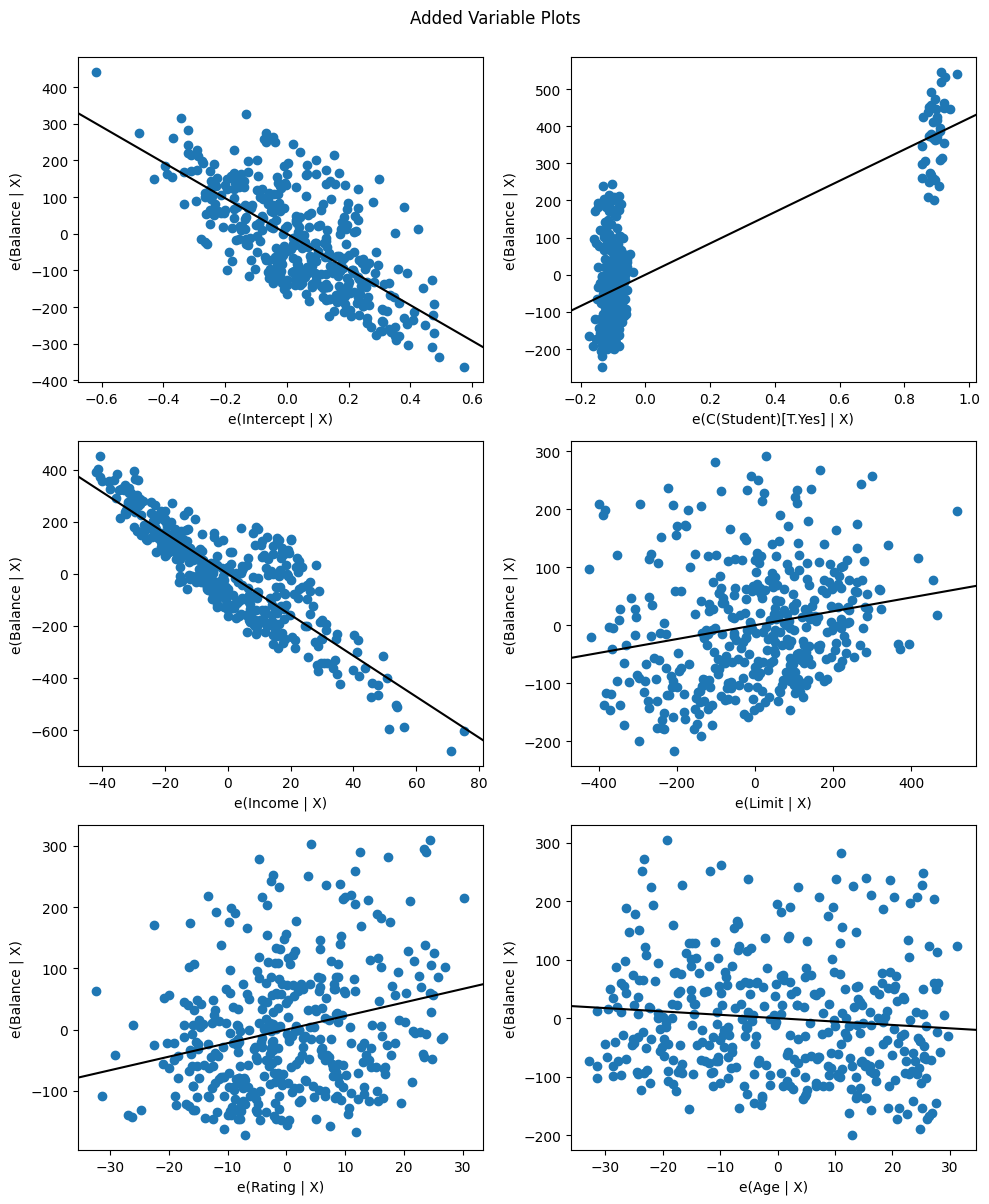

In [ ]:
fig = plt.figure(figsize=(10, 12))
plot_partregress_grid(model, fig=fig)
fig.suptitle("Added Variable Plots", y=1.0)
plt.tight_layout()
plt.show()

### Reading the AVPs quantitatively

Each panel above has a slope which is equal to the predictor's coefficient in the full fitted model. Since these slopes have different underlying units (per rating point, per dollar of credit limit, etc) we use **partial correlation** for comparisons.

It is the ordinary (Pearson) correlation between the two residual vectors the AVP plots: `Balance` with every predictor except $X_j$ partialled out, against $X_j$ with that same set partialled out. Being a correlation it is unit-free, runs from $-1$ to $+1$, and *is* comparable across predictors. It answers "how much of what is left of `Balance` does what is left of $X_j$ explain?"

You do not need the two auxiliary regressions to get it. It follows from the $t$-statistic the model already reports:

$$r_{\text{partial}} = \frac{t}{\sqrt{t^2 + \mathrm{df}_{\text{resid}}}}$$

The table below gives these quantities.

In [ ]:
# Partial regression coefficients
partials = pd.DataFrame({
    "coef":      model.params,
    "SE":        model.bse,
    "t":         model.tvalues,
    "partial r": model.tvalues / np.sqrt(model.tvalues**2 + model.df_resid),
}).drop("Intercept")

print(partials.round(4).to_string())

                       coef       SE        t  partial r
C(Student)[T.Yes]  421.4457  16.8273  25.0453     0.7837
Income              -7.8722   0.2376 -33.1318    -0.8578
Limit                0.1197   0.0278   4.3068     0.2120
Rating               2.2140   0.4137   5.3519     0.2603
Age                 -0.5761   0.2977  -1.9348    -0.0970


❓ **Question 3.1** For which predictor(s) does the AVP show a strong linear relationship after controlling for the others? Are there any signs of non-linearity or observations that appear to drive the slope?

*Your answer here:*

***

## Part 4: Influence Diagnostics

Leverage, Cook's distance and DFFITS all answer a version of "what happens if I delete this observation?". We attach all three to one frame and then look at it in three orderings.

In [ ]:
# One diagnostic frame built from quantities defined in Part 2
# Every view below is a different ordering of it.
diag = credit.copy()
diag["leverage"]  = leverage
diag["std_resid"] = studentised_ext
diag["cooks_d"]   = cooks_d
diag["dffits"]    = influence.dffits[0]      # .dffits returns (values, threshold)

# threholds
# leverage threshold computed above
cook_thresh_4n = 4 / n
dffits_thresh  = 2 * np.sqrt((p + 1) / n)

# Report red flags
print(f"n = {n:.0f},  p = {p:.0f},  mean leverage (p+1)/n = {(p + 1) / n:.4f}\n")
print(f"{'measure':10s} {'threshold':>10s} {'flagged':>8s}")
for col, thresh in [("leverage", lev_threshold), ("cooks_d", cook_thresh_4n),
                    ("dffits", dffits_thresh)]:
    print(f"{col:10s} {thresh:10.4f} {(diag[col].abs() > thresh).sum():8d}")

n = 400,  p = 5,  mean leverage (p+1)/n = 0.0150

measure     threshold  flagged
leverage       0.0300       38
cooks_d        0.0100       31
dffits         0.2449       31


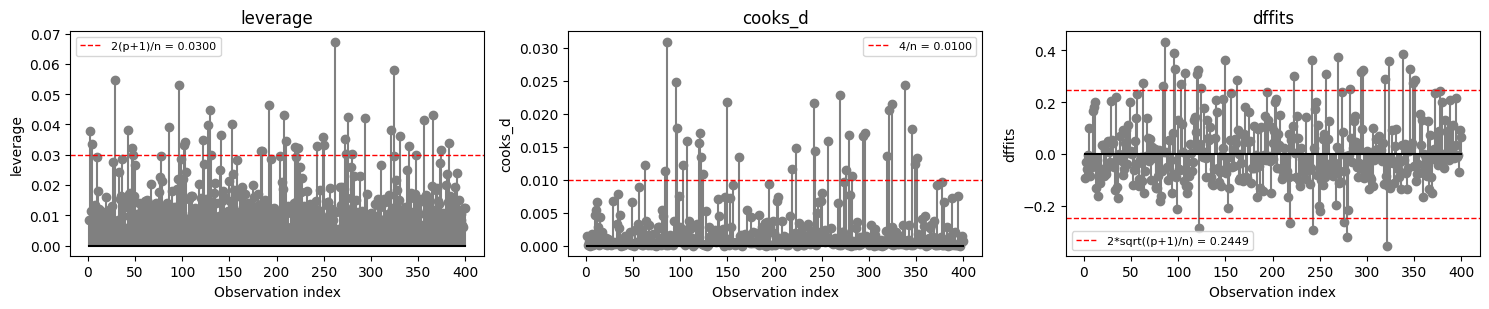

In [ ]:
# Columns used to describe a flagged observation: predictor space, then response.
id_cols   = ["Income", "Limit", "Rating", "Age", "Student", "Balance"]
stat_cols = ["leverage", "std_resid", "cooks_d", "dffits"]

# The three influence index plots, side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 3.2))
for ax, (col, thresh, formula) in zip(axes, [
        ("leverage", lev_threshold,  "2(p+1)/n"),
        ("cooks_d",  cook_thresh_4n, "4/n"),
        ("dffits",   dffits_thresh,  "2*sqrt((p+1)/n)")]):
    ax.stem(diag.index, diag[col], markerfmt='o', linefmt='grey', basefmt='black')
    ax.axhline(thresh, color='red', ls='--', lw=1, label=f"{formula} = {thresh:.4f}")
    if col == "dffits":
        ax.axhline(-thresh, color='red', ls='--', lw=1)
    ax.set(xlabel="Observation index", ylabel=col, title=col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 4.1  Leverage

$h_{ii}$ measures how unusual observation $i$ is in the **predictor** space, with no reference to its response value. Threshold: $h_{ii} > 2(p+1)/n$.

In [ ]:
print(f"Leverage threshold: {lev_threshold:.3f}")
print()
print("Top 10 by leverage:")
print(diag.nlargest(10, "leverage")[id_cols + stat_cols].round(4).to_string())

Leverage threshold: 0.030

Top 10 by leverage:
      Income  Limit  Rating  Age Student  Balance  leverage  std_resid  cooks_d  dffits
262  180.379   9310     665   67     Yes     1050    0.0674    -0.1299   0.0002 -0.0349
324  182.728  13913     982   98      No     1999    0.0579     1.4497   0.0215  0.3593
29   186.634  13414     949   41      No     1809    0.0548     0.8391   0.0068  0.2020
97    14.312   5382     367   59     Yes     1380    0.0530     1.3818   0.0178  0.3268
192  124.290   9560     701   52     Yes     1687    0.0464     0.6560   0.0035  0.1447
129  123.299   8376     610   89     Yes     1259    0.0449    -0.0689   0.0000 -0.0149
366  113.772   6442     489   69     Yes      790    0.0431    -0.6389   0.0031 -0.1356
208   10.842   4391     358   37     Yes     1216    0.0430     0.7079   0.0038  0.1500
276  163.329   8732     636   50      No      529    0.0426    -1.2477   0.0115 -0.2631
294  140.672  11200     817   46      No     1677    0.0421     1.5085   

Observation 262 has the **highest leverage in the dataset** with a value more than twice the threshold. However, the Cook's distance is only **0.0002**, because its residual is $-0.13$. The model fits it almost perfectly. Unusual in predictor space, but no influence.

> Note: Leverage measures *potential* influence; whether the potential is realised depends on the residual. Read the `leverage` and `std_resid` columns as a pair.

### 4.2  Cook's Distance

$D_i$ measures how far **all** the fitted values move when observation $i$ is deleted. It folds leverage and residual into one number:
$$D_i = \frac{r_i^2}{p+1} \cdot \frac{h_{ii}}{1 - h_{ii}}$$
A product, so an observation needs a non-trivial amount of both. Thresholds: $D_i > 4/n$ to investigate, $D_i > 1$ for serious concern.

In [ ]:
print(f"Soft D threshold: {cook_thresh_4n:.3f}")
print()
print(f"Exceeding D = 1: {(diag['cooks_d'] > 1).sum()}")
print("\nTop 10 by Cook's D:")
print(diag.nlargest(10, "cooks_d")[id_cols + stat_cols].round(4).to_string())

Soft D threshold: 0.010

Exceeding D = 1: 0

Top 10 by Cook's D:
      Income  Limit  Rating  Age Student  Balance  leverage  std_resid  cooks_d  dffits
86   152.298  12066     828   41      No     1779    0.0390     2.1482   0.0309  0.4328
96    14.084    855     120   46      No        0    0.0221     2.5895   0.0249  0.3891
338   12.414    855     119   32      No        0    0.0251     2.3981   0.0244  0.3846
269   25.988   1349     142   82      No        0    0.0194     2.6539   0.0228  0.3730
150   13.444    886     121   44      No        0    0.0213     2.4640   0.0217  0.3636
242   15.602    906     103   36      No        0    0.0148     2.9678   0.0216  0.3632
324  182.728  13913     982   98      No     1999    0.0579     1.4497   0.0215  0.3593
321   16.279   1160     126   78     Yes        5    0.0380    -1.7720   0.0206 -0.3523
97    14.312   5382     367   59     Yes     1380    0.0530     1.3818   0.0178  0.3268
346   30.012   1511     137   33      No        0    0.

Observation 86 leads, on the strength of its leverage.

Observations 96, 338, 269, 150, 242, 346 all share a signature: `Balance = 0` and a low credit limit. That is the floor in the response the residual plots already flagged.

They are influential as a **group**, and that exposes a blind spot shared by every measure in this section. Leverage, Cook's distance and DFFITS are all **leave-one-out**: each asks what changes when *one* observation is deleted. If we delete a single zero-balance customer, the fit barely moves because the rest are still there holding it in place. So each one is flagged as mild, and their group effect is invisible to all three.

### 4.3  DFFITS

Cook's distance asks how much **all** the fitted values move, DFFITS asks how much observation $i$'s **own** fitted value moves:
$$\text{DFFITS}_i = \frac{\hat{y}_i - \hat{y}_{i,(i)}}{\hat{\sigma}_{(i)}\sqrt{h_{ii}}}$$

It is **signed**, so it tells you the direction of the pull, which Cook's distance does not. Threshold: $|\text{DFFITS}_i| > 2\sqrt{(p+1)/n}$.

In [ ]:
print(f"DFFITS threshold: {dffits_thresh:.3f}")
print()

flagged_dffits = diag["dffits"].abs() > dffits_thresh
flagged_cooks  = diag["cooks_d"] > cook_thresh_4n

print(f"Flagged by DFFITS: {flagged_dffits.sum()}   "
      f"by Cook's D: {flagged_cooks.sum()}   "
      f"by both: {(flagged_dffits & flagged_cooks).sum()}")

# Ranked on magnitude: DFFITS is signed, so nlargest on the raw value would drop
# the observations pulling the fit downwards.
print("\nTop 10 by |DFFITS|:")
print(diag.reindex(diag["dffits"].abs().nlargest(10).index)
        [id_cols + stat_cols].round(4).to_string())

DFFITS threshold: 0.245

Flagged by DFFITS: 31   by Cook's D: 31   by both: 31

Top 10 by |DFFITS|:
      Income  Limit  Rating  Age Student  Balance  leverage  std_resid  cooks_d  dffits
86   152.298  12066     828   41      No     1779    0.0390     2.1482   0.0309  0.4328
96    14.084    855     120   46      No        0    0.0221     2.5895   0.0249  0.3891
338   12.414    855     119   32      No        0    0.0251     2.3981   0.0244  0.3846
269   25.988   1349     142   82      No        0    0.0194     2.6539   0.0228  0.3730
150   13.444    886     121   44      No        0    0.0213     2.4640   0.0217  0.3636
242   15.602    906     103   36      No        0    0.0148     2.9678   0.0216  0.3632
324  182.728  13913     982   98      No     1999    0.0579     1.4497   0.0215  0.3593
321   16.279   1160     126   78     Yes        5    0.0380    -1.7720   0.0206 -0.3523
346   30.012   1511     137   33      No        0    0.0157     2.5990   0.0177  0.3285
97    14.312   5382 

The two measures flag **exactly** the same observations here since both are built from leverage and residual, combined slightly differently.

It is common to report both. However, we do not treat them as independent confirmation.
***

### Exercise 4.1: Investigate, adjudicate, and test sensitivity

The thresholds above are deliberately sensitive. Flagging 30+ observations out of 400 means 30+ candidates to look at, not necessarily 30 problems.

In [ ]:
### YOUR CODE HERE
# Task: work on the observation with the highest Cook's distance.
# 1. Print all of its attributes, plus its leverage and externally studentised residual.
# 2. Compare it to the dataset mean and median for Balance, Income, Limit, Rating, Age.
# 3. Refit the model without it, and print a side-by-side comparison of the coefficients
#    with a percentage change column.
# Hint: cooks_d.idxmax() returns the LABEL of the maximum; credit.drop(index=...) drops
# that row.

❓ **Question 4.1** For the observation with the highest Cook's distance:

- Is it an outlier (large residual), a high-leverage point, or both?
- Is there a plausible, non-data-quality reason for its extreme values?
- How much do the coefficients move when it is excluded? Does any change sign or lose significance?
- What would you do with it, and how would you document that decision?

*Your answer here:*

***

## Part 5: Collinearity and VIF

In [ ]:
X = model.model.exog # predictors
names = model.model.exog_names # predictor names

vif_df = pd.DataFrame({
    "Predictor": names,
    "VIF": [variance_inflation_factor(X, i) for i in range(X.shape[1])]
})
vif_df = vif_df[vif_df["Predictor"] != "Intercept"].reset_index(drop=True)
print(vif_df.sort_values("VIF", ascending=False).to_string(index=False))

        Predictor        VIF
            Limit 161.875844
           Rating 161.232745
           Income   2.759848
              Age   1.038115
C(Student)[T.Yes]   1.005454


❓ **Question 5.1** Which predictor(s) have high VIF? Given what you know about credit card data, does this make substantive sense? What does a high VIF between `Limit` and `Rating` imply for the interpretation of their individual coefficients?

*Your answer here:*

### Exercise 5.2: remove one collinear predictor

In [ ]:
### YOUR CODE HERE
# Task:
# 1. Fit a reduced model dropping 'Rating' (which is strongly correlated with 'Limit').
# 2. Recompute VIF for the reduced model.
# 3. Compare coefficients and standard errors for 'Limit' between the full and reduced models.
# Does removing Rating change the Limit coefficient? Does its standard error change?


❓ **Question 5.2** After removing `Rating`:

- What happens to the VIF for `Limit`?
- What happens to the coefficient and standard error for `Limit`?
- Does the model fit ($R^2$, RSE) change meaningfully?
- Which model would you prefer, and why?

*Your answer here:*

***

## Part 6: Putting It All Together

The findings below are the ones you established in Parts 2–5. Fill in the **Action** column only: what you did, or would recommend, for each.

| Check | Finding | Action |
|---|---|---|
| Residuals vs Fitted | Pronounced U-shaped LOWESS; model underpredicts at both ends, overpredicts in the middle | |
| Normal Q–Q | Both tails above the line — right skew, driven by the 90 customers with `Balance = 0` | |
| Scale–Location | Non-flat, but hard to read cleanly while the mean function is misspecified | |
| Residuals vs Leverage | Nothing reaches $\pm 3$; 38 observations above the leverage threshold, all with moderate residuals | |
| Added variable plots | `Income` strongly negative; `Limit` and `Rating` both weak **and comparable**, because collinearity splits the shared signal; `Age` flat | |
| Cook's D / DFFITS | Nothing exceeds $D = 1$; obs 86 is the largest, high leverage rather than outlier; removing it changes nothing material | |
| VIF | `Limit` and `Rating` at ≈ 161, everything else below 3 | |

❓ **Question 6.1** Complete the Action column above.

❓ **Question 6.2** Does this model meet the Gauss–Markov assumptions well enough to trust the inference from `summary()`? If not, what is the most serious problem?

*Your answer here:*

***

## Lab Checklist

Before submitting, confirm you have:

- [ ] Run all demo cells without errors
- [ ] Completed Exercise 4.1 (investigate the most influential observation and test sensitivity)
- [ ] Completed Exercise 5.2 (VIF remedy — refit without `Rating`)
- [ ] Answered all ❓ questions in the markdown cells
- [ ] Filled in the Action column in the Part 6 table
